# Entendiendo los metodos de Regularizacion 
Nicole Chavarria

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

In [2]:
# Construcción de variables

x1 = np.arange(-1.3, 3.5, 0.125)

In [3]:
x2 = x1 * x1
x3 = x1 * x1 * x1

In [4]:

w = np.concatenate((np.vstack(x1), np.vstack(x2), np.vstack(x3)), axis=1)


In [6]:
X = pd.DataFrame(w, columns=['x1', 'x2', 'x3'])

In [7]:
X.head()

,x1,x2,x3
0,-1.300,1.690000,-2.197000
1,-1.175,1.380625,-1.622234
2,-1.050,1.102500,-1.157625
3,-0.925,0.855625,-0.791453
4,-0.800,0.640000,-0.512000


In [8]:
# Coeficientes de la función polinómica
w0 = 190
w1 = -85/3
w2 = -165
w3 = 160/3


In [9]:
# Introducir ruido
noise = 200 * (random.random() - 0.5)

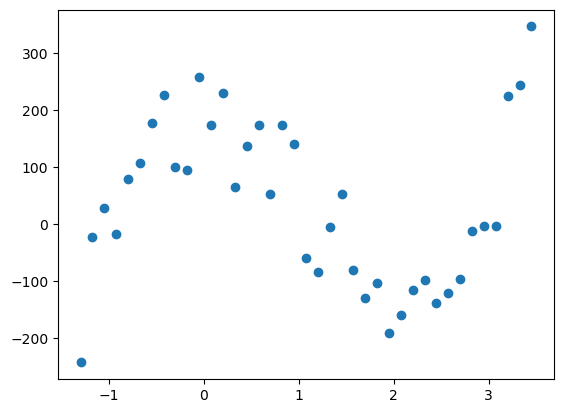

In [12]:
# Definimos nuestra variable de salida con algo de ruido para que nuestro problema
# no se reduzca simplemente a un problema de interpolación de puntos:

random.seed(1)
yreal = []
for x in x1:
  noise=200*(random.random() -0.5)
  cc = w3*np.power(x,3) + w2*np.power(x,2) + w1*x + w0 + noise
  yreal.append(cc)
  
  
plt.scatter(x1,yreal)
plt.show()

In [11]:
# Modelos entrenados
modelos = []
modelos.append(('LR', LinearRegression()))
modelos.append(('LASSO', Lasso(alpha=30)))
modelos.append(('RIDGE', Ridge(alpha=30)))
modelos.append(('EN', ElasticNet(alpha=1, l1_ratio=.5)))

In [14]:
yhat0 = []  # RLM
yhat1 = []  # LASSO
yhat2 = []  # RIDGE
yhat12 = []  # ElasticNet


In [15]:
for name, model in modelos:
    # entrenamos el modelo seleccionado y obtenemos sus predicciones:
    print("%s:" % name)
    mm = model.fit(X, np.ravel(yreal))
    yhat = mm.predict(X)

    print(mm.intercept_)      # por si deseas conocer w0.
    print(mm.coef_)           # despleguemos los pesos obtenidos

    if name == 'LR':
        yhat0.append(yhat)
        print('\n')
    elif name == 'LASSO':
        yhat1.append(yhat)
        print('\n')
    elif name == 'RIDGE':
        yhat2.append(yhat)
        print('\n')
    else:
        yhat12.append(yhat)


LR:
194.91638384474882
[ -40.14979812 -179.70350006   58.72754395]


LASSO:
117.1306942786351
[  -0.         -102.25253563   31.42721669]


RIDGE:
88.97294849574075
[-27.51573296 -61.84734688  22.38804271]


EN:
105.48167999947967
[-32.10655264 -79.34645456  28.06434904]


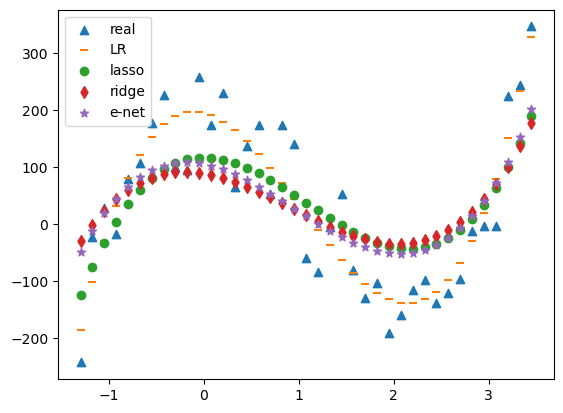

In [16]:
plt.scatter(x1, np.ravel(yreal), marker='^', label='real')  

plt.scatter(x1, np.ravel(yhat0), marker='_', label='LR')  
plt.scatter(x1, np.ravel(yhat1), marker='o', label='lasso')  
plt.scatter(x1, np.ravel(yhat2), marker='d', label='ridge')  
plt.scatter(x1, np.ravel(yhat12), marker='*', label='e-net')

plt.legend(loc=2)
plt.show()

Jueves 